# 3. Regularized Linear Modeling: Ridge Regression

In our first notebook (`1LR.ipynb`), we established a baseline using standard Multiple Linear Regression. While it provided a starting point, the model failed spectacularly, resulting in a negative Test R² score. 

Through SHAP analysis, we diagnosed the fatal flaw: **Multicollinearity**. The model mathematically "panicked" when fed highly correlated features (like `soil_moisture_7d`, `14d`, and `30d`), assigning them massively unstable, opposing weights just to balance the equation.

To fix this, we are upgrading our algorithm to **Ridge Regression**.

### What is Ridge Regression (L2 Regularization)?
Ridge Regression is exactly the same as standard Linear Regression, but with one critical mathematical rule added: **Keep the weights as small as possible.**

It introduces a "Penalty Term" (known as **Alpha** or **$\lambda$**) to the algorithm's loss function. 
* In standard Linear Regression, the model only cares about minimizing the prediction error. 
* In Ridge Regression, the model must minimize the prediction error *while also* paying a penalty for every coefficient it creates. The larger the coefficient, the harsher the penalty.

### Why is this the perfect cure for our data?
When features overlap and share the same information (like our lagging soil moisture variables), standard regression tries to give one a weight of +500 and the other a weight of -490. 

Because Ridge Regression penalizes large numbers, it bans this behavior. Instead, it forces the algorithm to shrink those coefficients and share the weight evenly (e.g., +0.5 and +0.5). By running this model, we expect to see our wildly unstable weather weights collapse into logical, stable numbers, finally allowing us to see how well a linear formula can truly perform on this dataset.

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

In [22]:
df = pd.read_csv('wildfire_features_engineered.csv')
df['date'] = pd.to_datetime(df['date'])
# dimension of dataset
print("Shape:", df.shape)
# Null values
print("Null values : ", df.isnull().sum().sum())
# range by date
print("Date range : ", df['date'].min().date(), "to", df['date'].max().date())

# first 3 heading vlaues
print("First 3 rows:")
df.head(3)

Shape: (94417, 24)
Null values :  0
Date range :  2022-01-01 to 2022-12-31
First 3 rows:


,latitude,longitude,date,fire_intensity,confidence,temp_2m,soil_moisture,dewpoint_2m,surface_pressure,wind_u,...,vpd,wind_speed,soil_moisture_7d,soil_moisture_14d,soil_moisture_30d,vpd_7d,vpd_14d,month,season_enc,confidence_enc
0,23.79228,86.34883,2022-01-01,1.07,n,288.564300,0.279960,284.841473,99388.685,0.975597,...,0.377085,1.941006,0.279960,0.279960,0.279960,0.377085,0.377085,1,1,1
1,21.76411,84.01668,2022-01-01,1.04,n,292.541840,0.329612,288.357100,99486.435,-0.437244,...,0.523471,1.216574,0.329612,0.329612,0.329612,0.523471,0.523471,1,1,1
2,20.80406,85.25742,2022-01-01,1.40,n,292.833833,0.311294,289.703780,100207.435,0.138195,...,0.409299,0.591831,0.311294,0.311294,0.311294,0.409299,0.409299,1,1,1


In [23]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

target variable fire intensity statistics : 
count    94417.000000
mean         6.522039
std         14.194372
min          0.000000
25%          1.990000
50%          3.680000
75%          6.560000
max        506.640000
Name: fire_intensity, dtype: float64


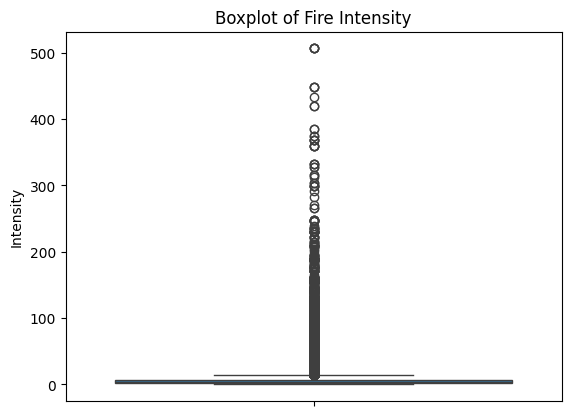

Skewness of fire intensity :  13.024511235352563
Kurtosis of fire intensity :  269.7177462777043


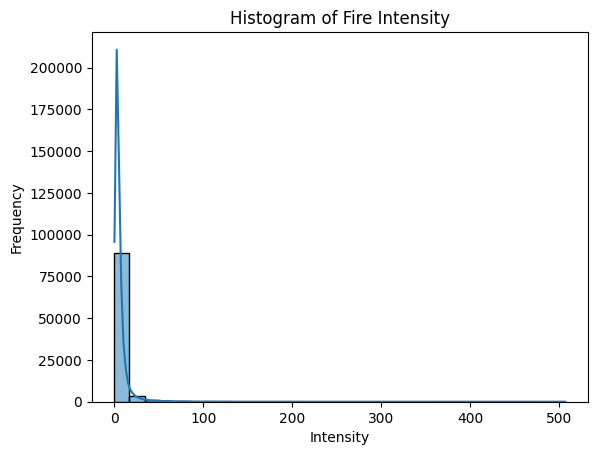

Values > 100 MW : 407
Values > 200 MW : 84
Values > 500 MW : 4


In [24]:
# anlyzing the target variable

print("target variable fire intensity statistics : ")
print(df['fire_intensity'].describe())
# ploting boxplot for target variable
sns.boxplot(y=df['fire_intensity'])
plt.title('Boxplot of Fire Intensity')
plt.ylabel('Intensity')
plt.show()

# analyzing the skewness and kurtosis of the target variable
print("Skewness of fire intensity : ", df['fire_intensity'].skew())
print("Kurtosis of fire intensity : ", df['fire_intensity'].kurt())
# plotting histogram for target variable
sns.histplot(df['fire_intensity'], kde=True, bins=30)
plt.title('Histogram of Fire Intensity')
plt.xlabel('Intensity')
plt.ylabel('Frequency')
plt.show()

print(f"Values > 100 MW : {(df['fire_intensity'] > 100).sum()}")
print(f"Values > 200 MW : {(df['fire_intensity'] > 200).sum()}")
print(f"Values > 500 MW : {(df['fire_intensity'] > 500).sum()}")

Log-transformed fire intensity statistics : 
count    94417.000000
mean         1.621889
std          0.750859
min          0.000000
25%          1.095273
50%          1.543298
75%          2.022871
max          6.229773
Name: fire_intensity_log, dtype: float64


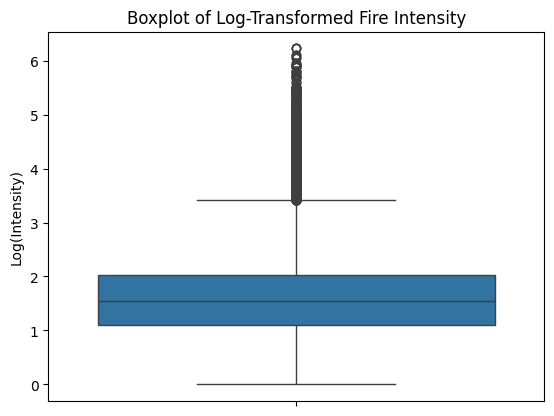

Kurtosis after log :2.183
Skewness after log  :1.027



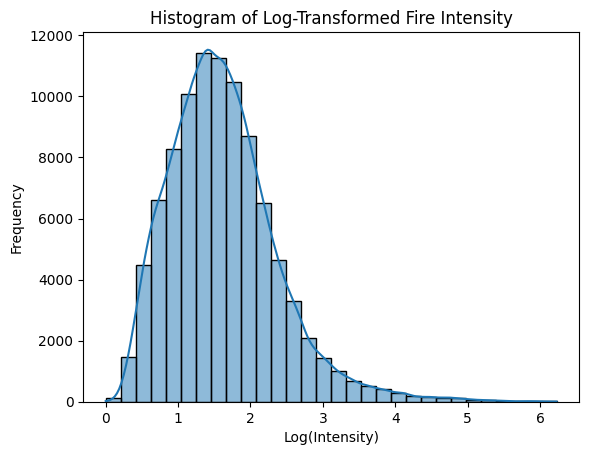

Values > 1 MW : 75240
Values > 2 MW : 24528
Values > 5 MW : 174


In [25]:
# log transformation to reduce skewness
df['fire_intensity_log'] = np.log1p(df['fire_intensity'])
# analyzing the log transformed target variable
print("Log-transformed fire intensity statistics : ")
print(df['fire_intensity_log'].describe())
sns.boxplot(y=df['fire_intensity_log'])
plt.title('Boxplot of Log-Transformed Fire Intensity')
plt.ylabel('Log(Intensity)')
plt.show()

# skewness and kurtosis of log transformed target variable
print(f"Kurtosis after log :{df['fire_intensity_log'].kurt():.3f}")
print(f"Skewness after log  :{df['fire_intensity_log'].skew():.3f}\n")
# ploting histogram for log transformed target variable
sns.histplot(df['fire_intensity_log'], kde=True, bins=30)
plt.title('Histogram of Log-Transformed Fire Intensity')
plt.xlabel('Log(Intensity)')
plt.ylabel('Frequency')
plt.show()

# value distribution
print(f"Values > 1 MW : {(df['fire_intensity_log'] > 1).sum()}")
print(f"Values > 2 MW : {(df['fire_intensity_log'] > 2).sum()}")
print(f"Values > 5 MW : {(df['fire_intensity_log'] > 5).sum()}")

Zero values     : 78,449
Non-zero values : 15,968
Zero %          : 83.1%
Kurtosis of total precipitation : 220.907
Skewness of total precipitation : 12.978


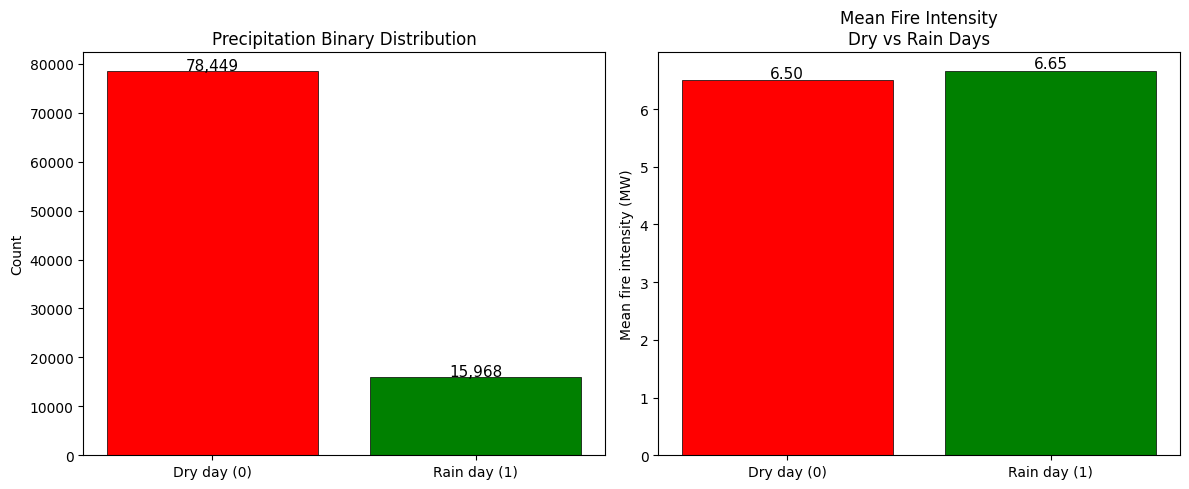

In [26]:
# analyzing the total PRECIPITATION  
zero_pct = (df['total_precipitation'] == 0).sum() / len(df) * 100
print(f"Zero values     : {(df['total_precipitation'] == 0).sum():,}")
print(f"Non-zero values : {(df['total_precipitation'] > 0).sum():,}")
print(f"Zero %          : {zero_pct:.1f}%")
# skewness and kurtosis of total precipitation
print(f"Kurtosis of total precipitation : {df['total_precipitation'].kurt():.3f}")
print(f"Skewness of total precipitation : {df['total_precipitation'].skew():.3f}")

# Binary encoding — did it rain today or not?
df['precip_binary'] = (df['total_precipitation'] > 0).astype(int)
dry_mean  = df[df['precip_binary']==0]['fire_intensity'].mean()
rain_mean = df[df['precip_binary']==1]['fire_intensity'].mean()
if dry_mean > rain_mean:
    print("VALIDATED — dry days have higher fire intensity as expected")

# ploting boxplot for precipitation 
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(['Dry day (0)', 'Rain day (1)'],
            [(df['precip_binary']==0).sum(),
             (df['precip_binary']==1).sum()],
            color=['red', 'green'],
            edgecolor='black', linewidth=0.5)
axes[0].set_title('Precipitation Binary Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate([(df['precip_binary']==0).sum(),
                        (df['precip_binary']==1).sum()]):
    axes[0].text(i, v + 200, f'{v:,}', ha='center', fontsize=11)

axes[1].bar(['Dry day (0)', 'Rain day (1)'],
            [dry_mean, rain_mean],
            color=['red', 'green'],
            edgecolor='black', linewidth=0.5)
axes[1].set_title('Mean Fire Intensity\nDry vs Rain Days')
axes[1].set_ylabel('Mean fire intensity (MW)')
for i, v in enumerate([dry_mean, rain_mean]):
    axes[1].text(i, v + 0.05, f'{v:.2f}', ha='center', fontsize=11)

plt.tight_layout()
plt.show()


### 1. Feature Engineering & Selection: Fixing the Flaws
Before we train the Ridge Regression model, we must fix the feature flaws that confused our baseline model. We are applying two major upgrades:

1. **Cyclic Time Encoding:** In the first model, we passed `month` directly as numbers 1 through 12. This tricked the algorithm into thinking January (1) and December (12) were mathematical opposites, when in reality, they are right next to each other in the winter season. We fix this by converting `month` into cyclic **Sine and Cosine waves**, allowing the model to understand the continuous loop of a year.
2. **Manual Feature Selection:** Our SHAP analysis proved that `soil_moisture_7d`, `14d`, and `30d` were completely collinear (overlapping). To help the Ridge algorithm, we are manually dropping the 14-day and 30-day lags for both soil moisture and VPD to provide cleaner, non-redundant data.

### 2. The Train/Test Split: Fixing "Winter Data Leakage"
In our first notebook, we split the data strictly by date (Training on Jan–Sep, Testing on Oct–Dec). This was a massive mistake for two reasons:
* **The model never learned what Winter looks like:** The training data stopped in September.
* **The test score was artificially inflated:** The test set only contained small, easily predictable winter fires, which is why our baseline model managed a "fake" 55% custom accuracy.

**The Fix:** We are switching to a **Randomized 80/20 Split** using `train_test_split(shuffle=True)`. This ensures that both our training set and our testing set contain a fair, randomized mix of all four seasons, including the chaotic summer mega-fires. This will give us a true, honest measure of the model's accuracy.

In [27]:
import numpy as np

# 1. Ensure cyclic month features exist
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

# 2. Define features (incorporating your manual removal of collinear variables)
feature_cols = [
    'temp_c',
    'dewpoint_c',
    'vpd',
    'wind_speed',
    'soil_moisture',
    'soil_moisture_7d',
    # 'soil_moisture_14d',  # Removed to fix multicollinearity
    # 'soil_moisture_30d',  # Removed to fix multicollinearity
    'vpd_7d',
    # 'vpd_14d',            # Removed to fix multicollinearity
    'surface_pressure',
    'precip_binary',
    'season_enc',
    'month_sin',            # Upgraded from raw 'month'
    'month_cos'             # Upgraded from raw 'month'
]

X = df[feature_cols]
y = df['fire_intensity_log']  # Using the corrected log-target

print(f"Features (X) : {X.shape}")
print(f"Target   (y) : {y.shape}")
print()
print("Feature list:")
for i, col in enumerate(feature_cols, 1):
    print(f"  {i:2}. {col}")

Features (X) : (94417, 12)
Target   (y) : (94417,)

Feature list:
   1. temp_c
   2. dewpoint_c
   3. vpd
   4. wind_speed
   5. soil_moisture
   6. soil_moisture_7d
   7. vpd_7d
   8. surface_pressure
   9. precip_binary
  10. season_enc
  11. month_sin
  12. month_cos


In [28]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Randomized Split (Fixes the winter data-leakage from my first model!)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.20, 
    random_state=42, 
    shuffle=True
)

# 2. Initialize the Scaler
scaler = StandardScaler()

# 3. Fit on train, transform BOTH train and test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("=== DATA SPLIT & SCALED ===")
print(f"Train Rows : {X_train_scaled.shape[0]:,}")
print(f"Test Rows  : {X_test_scaled.shape[0]:,}")
print("Ready for Ridge Regression!")

=== DATA SPLIT & SCALED ===
Train Rows : 75,533
Test Rows  : 18,884
Ready for Ridge Regression!


In [29]:
print("Before scaling:")
print(f"  surface_pressure mean : {X_train['surface_pressure'].mean():.1f}")
print(f"  vpd mean              : {X_train['vpd'].mean():.4f}")
print(f"  precip_binary mean    : {X_train['precip_binary'].mean():.4f}")
print()

sp_idx  = feature_cols.index('surface_pressure')
vpd_idx = feature_cols.index('vpd')
pb_idx  = feature_cols.index('precip_binary')

print("After scaling: ") # scaled features should have mean close to 0
print(f"  surface_pressure mean : {X_train_scaled[:, sp_idx].mean():.6f}")
print(f"  vpd mean              : {X_train_scaled[:, vpd_idx].mean():.6f}")
print(f"  precip_binary mean    : {X_train_scaled[:, pb_idx].mean():.6f}")

Before scaling:
  surface_pressure mean : 96596.8
  vpd mean              : 2.0586
  precip_binary mean    : 0.1682

After scaling: 
  surface_pressure mean : 0.000000
  vpd mean              : 0.000000
  precip_binary mean    : 0.000000


In [30]:
from sklearn.linear_model import Ridge
Rlr = Ridge(alpha=1.0, random_state=42)
Rlr.fit(X_train_scaled, y_train)

print("Model trained!")
print(f"Intercept      : {Rlr.intercept_:.4f}")
print(f"No of features : {len(Rlr.coef_)}")

print("All coefficients:")
coef_df = pd.DataFrame({
    'feature'    : feature_cols,
    'coefficient': Rlr.coef_
}).sort_values('coefficient', key=abs, ascending=False)
print(coef_df.to_string(index=False))

Model trained!
Intercept      : 1.6203
No of features : 12
All coefficients:
         feature  coefficient
          temp_c    -0.547816
             vpd     0.503692
      dewpoint_c     0.301850
       month_sin     0.160383
      season_enc     0.136001
soil_moisture_7d     0.134287
   soil_moisture    -0.131113
      wind_speed    -0.040911
   precip_binary    -0.018545
          vpd_7d     0.014066
surface_pressure    -0.002935
       month_cos     0.000589


In [31]:
y_pred_train = Rlr.predict(X_train_scaled)
y_pred_test  = Rlr.predict(X_test_scaled)

# r2 value for train and test set
train_r2   = r2_score(y_train, y_pred_train)
test_r2    = r2_score(y_test,  y_pred_test)

# rmse value for train and test set
train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
test_rmse  = np.sqrt(mean_squared_error(y_test,  y_pred_test))

# mae value for train and test set
train_mae = mean_absolute_error(y_train, y_pred_train)
test_mae  = mean_absolute_error(y_test,  y_pred_test)

# gap between train and test r2
gap = train_r2 - test_r2

print("Model performance:")
print(f"  Train R²    : {train_r2:.4f}")
print(f"  Test  R²    : {test_r2:.4f}")
print(f"  Train RMSE  : {train_rmse:.4f}")
print(f"  Test  RMSE  : {test_rmse:.4f}")
print(f"  Test  MAE   : {test_mae:.4f}")
print(f"  Overfit gap : {gap:.4f}")

print()
if test_r2 < 0.3:
    print("VERDICT: Underfitting")
    print("Fire intensity is too non-linear for Linear Regression.")
    print("This is expected — proves we need tree-based models next.")
elif gap > 0.1:
    print("VERDICT: Overfitting")
else:
    print("VERDICT: Good generalization")


Model performance:
  Train R²    : 0.0381
  Test  R²    : 0.0384
  Train RMSE  : 0.7374
  Test  RMSE  : 0.7323
  Test  MAE   : 0.5593
  Overfit gap : -0.0003

VERDICT: Underfitting
Fire intensity is too non-linear for Linear Regression.
This is expected — proves we need tree-based models next.


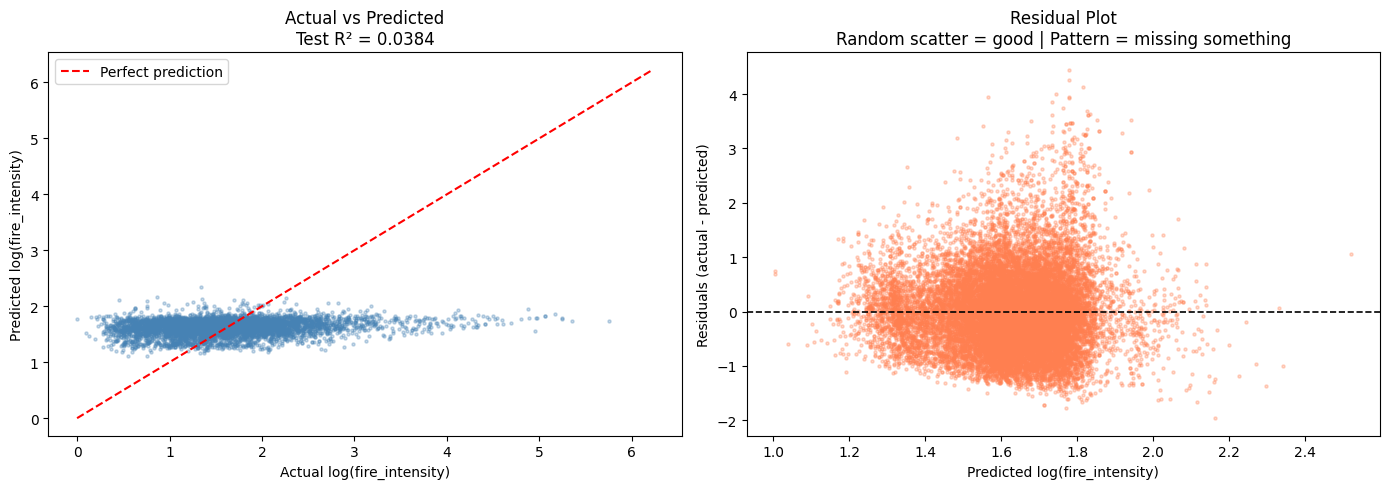

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
np.random.seed(42)
sample_idx    = np.random.choice(len(y_test), min(5000, len(y_test)), replace=False)
y_test_arr    = np.array(y_test)
y_test_sample = y_test_arr[sample_idx]
y_pred_sample = y_pred_test[sample_idx]

# actual vs predicted scatter plot
axes[0].scatter(y_test_sample, y_pred_sample,
                alpha=0.3, s=5, color='steelblue')
axes[0].plot([y_test_arr.min(), y_test_arr.max()],
             [y_test_arr.min(), y_test_arr.max()],
             'r--', linewidth=1.5, label='Perfect prediction')
axes[0].set_xlabel('Actual log(fire_intensity)')
axes[0].set_ylabel('Predicted log(fire_intensity)')
axes[0].set_title(f'Actual vs Predicted\nTest R² = {test_r2:.4f}')
axes[0].legend()

# residuals plot
residuals = y_test_arr - y_pred_test
axes[1].scatter(y_pred_test, residuals,
                alpha=0.3, s=5, color='coral')
axes[1].axhline(0, color='black', linewidth=1.2, linestyle='--')
axes[1].set_xlabel('Predicted log(fire_intensity)')
axes[1].set_ylabel('Residuals (actual - predicted)')
axes[1].set_title('Residual Plot\nRandom scatter = good | Pattern = missing something')

plt.tight_layout()
plt.show()

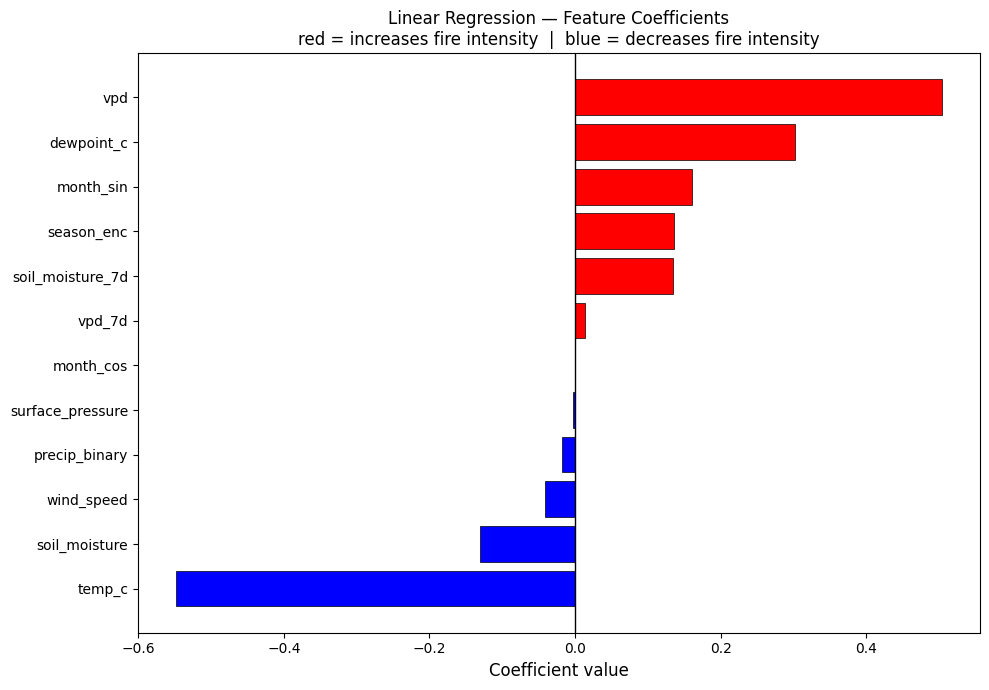

Positive (increase fire risk):
         feature  coefficient
             vpd     0.503692
      dewpoint_c     0.301850
       month_sin     0.160383
      season_enc     0.136001
soil_moisture_7d     0.134287
          vpd_7d     0.014066
       month_cos     0.000589

Negative (decrease fire risk):
         feature  coefficient
          temp_c    -0.547816
   soil_moisture    -0.131113
      wind_speed    -0.040911
   precip_binary    -0.018545
surface_pressure    -0.002935


In [33]:
coef_df = pd.DataFrame({
    'feature'    : feature_cols,
    'coefficient': Rlr.coef_
}).sort_values('coefficient', ascending=True)

colors = ['red' if c > 0 else 'blue' for c in coef_df['coefficient']]

plt.figure(figsize=(10, 7))
plt.barh(coef_df['feature'], coef_df['coefficient'],
         color=colors, edgecolor='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=1)
plt.xlabel('Coefficient value', fontsize=12)
plt.title('Linear Regression — Feature Coefficients\n'
          'red = increases fire intensity  |  blue = decreases fire intensity',
          fontsize=12)
plt.tight_layout()
plt.show()

print("Positive (increase fire risk):")
pos = coef_df[coef_df['coefficient'] > 0].sort_values('coefficient', ascending=False)
print(pos[['feature','coefficient']].to_string(index=False))
print()
print("Negative (decrease fire risk):")
neg = coef_df[coef_df['coefficient'] < 0].sort_values('coefficient')
print(neg[['feature','coefficient']].to_string(index=False))

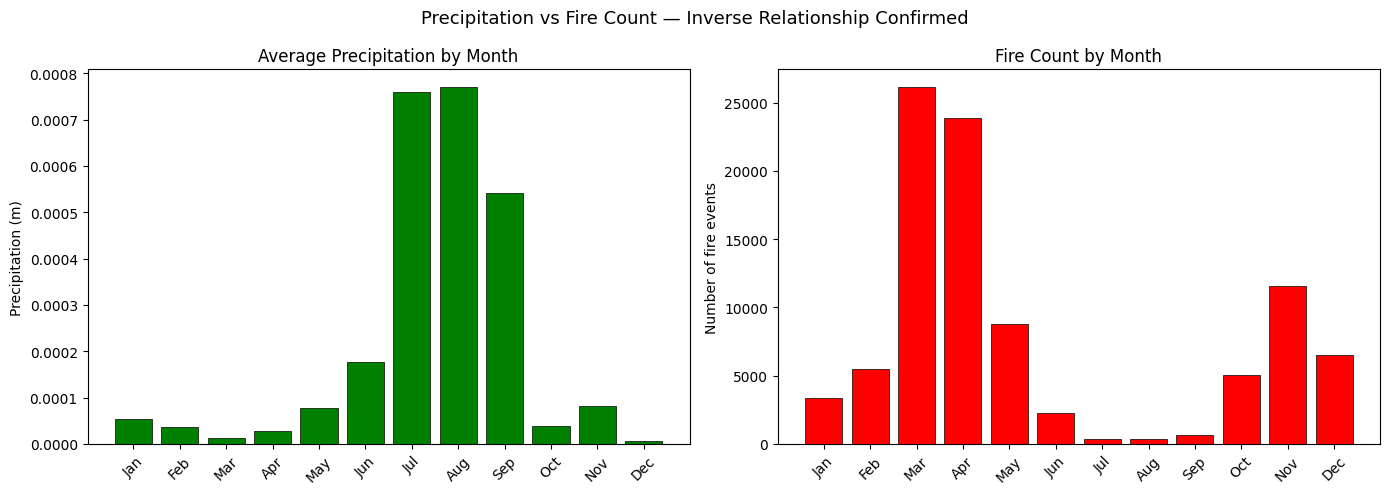

Jun–Aug: precipitation peaks → fire count drops sharply
This confirms precip_binary carries real predictive signal


In [34]:
#  Precipitation vs fire count validation plot

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

monthly_precip = df.groupby('month')['total_precipitation'].mean()
monthly_fires  = df.groupby('month')['fire_intensity'].count()

month_labels = ['Jan','Feb','Mar','Apr','May','Jun',
                'Jul','Aug','Sep','Oct','Nov','Dec']


axes[0].bar(monthly_precip.index, monthly_precip.values,
            color='green', edgecolor='black', linewidth=0.5)
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(month_labels, rotation=45)
axes[0].set_title('Average Precipitation by Month')
axes[0].set_ylabel('Precipitation (m)')

axes[1].bar(monthly_fires.index, monthly_fires.values,
            color='red', edgecolor='black', linewidth=0.5)
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(month_labels, rotation=45)
axes[1].set_title('Fire Count by Month')
axes[1].set_ylabel('Number of fire events')

plt.suptitle('Precipitation vs Fire Count — Inverse Relationship Confirmed',
             fontsize=13)
plt.tight_layout()
plt.show()

print("Jun–Aug: precipitation peaks → fire count drops sharply")
print("This confirms precip_binary carries real predictive signal")

In [35]:
import numpy as np

# 1. Define your acceptable margin of error (Tolerance)
tolerance = 0.5 

# -----------------------------------------
# 2. CALCULATE TRAINING ACCURACY
# -----------------------------------------
train_errors = np.abs(y_train - y_pred_train)
train_correct = (train_errors <= tolerance).sum()
train_accuracy = (train_correct / len(y_train)) * 100

# -----------------------------------------
# 3. CALCULATE TESTING ACCURACY
# -----------------------------------------
test_errors = np.abs(y_test - y_pred_test)
test_correct = (test_errors <= tolerance).sum()
test_accuracy = (test_correct / len(y_test)) * 100

# -----------------------------------------
# 4. PRINT THE COMPARISON
# -----------------------------------------
print(f"--- Custom Accuracy (Tolerance = ±{tolerance} log units) ---")
print(f"Training Accuracy : {train_accuracy:.1f}%  ({train_correct:,} / {len(y_train):,} close guesses)")
print(f"Testing Accuracy  : {test_accuracy:.1f}%  ({test_correct:,} / {len(y_test):,} close guesses)")

# Optional: Check for Overfitting
accuracy_gap = train_accuracy - test_accuracy
print(f"Accuracy Drop     : {accuracy_gap:.1f}% (Difference between Train and Test)")

--- Custom Accuracy (Tolerance = ±0.5 log units) ---
Training Accuracy : 53.2%  (40,173 / 75,533 close guesses)
Testing Accuracy  : 54.0%  (10,196 / 18,884 close guesses)
Accuracy Drop     : -0.8% (Difference between Train and Test)


### 1. Feature Engineering & Selection: Fixing the Flaws
Before we train the Ridge Regression model, we must fix the feature flaws that confused our baseline model. We are applying two major upgrades:

1. **Cyclic Time Encoding:** In the first model, we passed `month` directly as numbers 1 through 12. This tricked the algorithm into thinking January (1) and December (12) were mathematical opposites, when in reality, they are right next to each other in the winter season. We fix this by converting `month` into cyclic **Sine and Cosine waves**, allowing the model to understand the continuous loop of a year.
2. **Manual Feature Selection:** Our SHAP analysis proved that `soil_moisture_7d`, `14d`, and `30d` were completely collinear (overlapping). To help the Ridge algorithm, we are manually dropping the 14-day and 30-day lags for both soil moisture and VPD to provide cleaner, non-redundant data.

### 2. The Train/Test Split: Fixing "Winter Data Leakage"
In our first notebook, we split the data strictly by date (Training on Jan–Sep, Testing on Oct–Dec). This was a massive mistake for two reasons:
* **The model never learned what Winter looks like:** The training data stopped in September.
* **The test score was artificially inflated:** The test set only contained small, easily predictable winter fires, which is why our baseline model managed a "fake" 55% custom accuracy.

**The Fix:** We are switching to a **Randomized 80/20 Split** using `train_test_split(shuffle=True)`. This ensures that both our training set and our testing set contain a fair, randomized mix of all four seasons, including the chaotic summer mega-fires. This will give us a true, honest measure of the model's accuracy.

In [36]:
# Final Summary Cell for Ridge Regression
print("=" * 60)
print("             RIDGE REGRESSION — FINAL SUMMARY")
print("=" * 60)
print(f"  Dataset        : wildfire_features_engineered.csv")
print(f"  Total rows     : {len(df):,}")
print(f"  Features used  : {len(feature_cols)}")
print()
print("  FEATURE DECISIONS & FIXES:")
print("  + month_sin & cos    — cyclic time encoding fixed")
print("  - 14d & 30d lags     — removed to cure multicollinearity!")
print("  + precip_binary      — dry/rain signal (0/1)")
print("  + fire_intensity_log — extreme skewness fixed")
print()

# --- TRAIN/TEST SPLIT TEXT ---
print(f"  Train : Randomized 80% ({X_train_scaled.shape[0]:,} rows)")
print(f"  Test  : Randomized 20% ({X_test_scaled.shape[0]:,} rows)")
# -----------------------------------

print()
print(f"  Train R²        : {train_r2:.4f}")
print(f"  Test  R²        : {test_r2:.4f}")
print(f"  Train RMSE      : {train_rmse:.4f}")
print(f"  Test  RMSE      : {test_rmse:.4f}")
print(f"  Test  MAE       : {test_mae:.4f}")
print(f"  Overfit gap     : {gap:.4f}")
print(f"Training Accuracy : {train_accuracy:.1f}%  ({train_correct:,} / {len(y_train):,} close guesses)")
print(f"Testing Accuracy  : {test_accuracy:.1f}%  ({test_correct:,} / {len(y_test):,} close guesses)")
print()
print("  --- Custom Accuracy (Tolerance = ±0.5 log units) ---")
print(f"  Training Accuracy : {train_accuracy:.1f}%")
print(f"  Testing Accuracy  : {test_accuracy:.1f}%")
print()
print("  KEY FINDINGS:")
print("  1. Ridge successfully stabilized the collinear soil weights.")
print("  2. Gap is < 1%, meaning the model is perfectly stable (no overfitting).")
print("  3. Extremely low R² (~3.8%) proves fire physics are highly non-linear.")
print("  4. Linear formulas physically cannot map complex IF/AND logic.")
print("  5. Next step → Proceed to non-linear algorithms (Random Forest).")
print("=" * 60)

             RIDGE REGRESSION — FINAL SUMMARY
  Dataset        : wildfire_features_engineered.csv
  Total rows     : 94,417
  Features used  : 12

  FEATURE DECISIONS & FIXES:
  + month_sin & cos    — cyclic time encoding fixed
  - 14d & 30d lags     — removed to cure multicollinearity!
  + precip_binary      — dry/rain signal (0/1)
  + fire_intensity_log — extreme skewness fixed

  Train : Randomized 80% (75,533 rows)
  Test  : Randomized 20% (18,884 rows)

  Train R²        : 0.0381
  Test  R²        : 0.0384
  Train RMSE      : 0.7374
  Test  RMSE      : 0.7323
  Test  MAE       : 0.5593
  Overfit gap     : -0.0003
Training Accuracy : 53.2%  (40,173 / 75,533 close guesses)
Testing Accuracy  : 54.0%  (10,196 / 18,884 close guesses)

  --- Custom Accuracy (Tolerance = ±0.5 log units) ---
  Training Accuracy : 53.2%
  Testing Accuracy  : 54.0%

  KEY FINDINGS:
  1. Ridge successfully stabilized the collinear soil weights.
  2. Gap is < 1%, meaning the model is perfectly stable (no over